# Multimodal Box Office Prediction and Film Investment Decision Support
### Capstone Project

## Research Motivation

Film investment decisions are highly uncertain and financially risky. Investors must decide whether to finance or promote a film before its commercial performance is realized.

This capstone expands on a course project that used TF-IDF on keywords and genres to predict box-office revenue (Ridge / Random Forest, random train/test split, test R² ≈ 0.46). That earlier version had three material limitations:

1. **Structured metadata was prepared but never integrated into the model.** Budget, runtime, release timing, and other numeric signals were computed but the final pipeline ran on TF-IDF text only.
2. **Highly skewed revenue with blockbuster outliers** systematically broke the regressors at the top of the distribution.
3. **Random train/test split** does not simulate real-world forecasting, where we must predict the future from the past.

This notebook addresses all three by: expanding the feature set (cast, director, budget, runtime, release date, overview, tagline), building a proper multimodal pipeline that fuses text + structured + categorical features, switching to a **time-aware** train/val/test split, and reporting **investment-specific metrics** (top-10% precision, decile lift, hypothetical ROI) alongside the standard RMSE/R².

## Research Question

> Can a multimodal machine learning model that integrates text (overview, tagline, keywords), structured metadata (budget, runtime, release timing), categorical signals (genres, languages, production companies), and talent signals (director historical performance) predict box-office revenue — and *rank* films by investment attractiveness — more accurately than a TF-IDF baseline, when evaluated under a time-aware protocol that simulates real-world pre-release forecasting?

## Framing as Machine Learning Tasks

We formulate three related tasks:

1. **Regression** — predict `log1p(total_box_office)`. Metrics: RMSE, MAE, R² on log scale; Spearman ρ on rank.
2. **Ranking for investment** — within each release year, rank films by predicted revenue. Metrics: top-10% precision, decile lift, hypothetical ROI of a top-k portfolio.
3. **Profitability classification** — binary: revenue > 2.5 × budget (industry theatrical break-even rule of thumb). Metric: AUC.

**Input feature groups:**
- Text: `overview + tagline + keywords` via TF-IDF
- Structured numeric: `budget`, `runtime`, `vote_count`, `popularity`, `director_mean_log_revenue_prior`, `director_n_prior_films`, `release_month`
- Categorical: `original_language`, `primary_genre`, `release_quarter`, `is_summer`, `is_holiday_window`


## Setup

In [77]:
import os
import re
import time
import warnings
from collections import defaultdict
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import plot_tree
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    roc_auc_score, silhouette_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from matplotlib.ticker import FuncFormatter
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings("ignore")
sns.set_style("darkgrid")
pd.options.display.float_format = "{:.3f}".format
np.random.seed(42)

# ------------------------------------------------------------------
# Paths and API key
# ------------------------------------------------------------------
DATA_DIR = Path("data")                    # put your three yearly CSVs + movies.csv here
CACHE_DIR = Path("cache"); CACHE_DIR.mkdir(exist_ok=True)

# TMDB API key — set via environment variable or paste here
TMDB_API_KEY = "b1abff07eea1fab3a2c28bd8fe5fab5d"

# Change the format of the large revenue number to make it more readable
def format_number(x, pos=None):
    if pd.isna(x):
        return "Missing"
    elif abs(x) >= 1_000_000_000:
        return f"{x / 1_000_000_000:g}B"
    elif abs(x) >= 1_000_000:
        return f"{x / 1_000_000:g}M"
    elif abs(x) >= 1_000:
        return f"{x / 1_000:g}K"
    else:
        return str(int(x))

# Data Collection

The data pipeline has three sources:

1. **Box Office Mojo yearly CSVs** (domestic, foreign, worldwide revenue) — three files for 2000, 2010, 2024-era that together give ~5,000 films.
2. **MovieLens `movies.csv`** — used in the course project to back-fill genres via title matching.
3. **TMDB API** — the enrichment source. For the capstone we request **expanded fields**: `budget`, `runtime`, `release_date`, `imdb_id`, `overview`, `tagline`, `director`, top-5 `cast`, writers, production companies/countries, spoken languages, on top of the genres/keywords/vote signals the course project already used.

The big upgrade over the course project: one combined TMDB request per film (using `append_to_response=credits,keywords`) now returns everything in a single call. This halves the API traffic and, more importantly, gives us **budget and release_date**, which are essential for computing ROI and for time-aware evaluation.


### Step 1 — Load the three yearly Box Office CSVs

In [3]:
# Adjust paths as needed. These are the same CSVs used in the course project.
df_2000 = pd.read_csv("/Users/joezhou/Desktop/UChi/学习文件/capstone/dataset/box office/2000-2009 Movies Box Ofice Collection.csv")
df_2010 = pd.read_csv("/Users/joezhou/Desktop/UChi/学习文件/capstone/dataset/box office/2010-2024 Movies Box Ofice Collection.csv")
df_2024 = pd.read_csv("/Users/joezhou/Desktop/UChi/学习文件/capstone/dataset/box office/2024 Movies Box Ofice Collection.csv")

print("Shapes:", df_2000.shape, df_2010.shape, df_2024.shape)
df_2000.head()


Shapes: (2000, 8) (2800, 8) (200, 8)


,Unnamed: 0,Release Group,Worldwide,Domestic,Domestic_percent,Foreign,Foreign_percent,year
0,0,Mission: Impossible II,"54,63,88,108","21,54,09,889",39.40%,"33,09,78,219",60.60%,2000
1,1,Gladiator,"46,05,83,960","18,77,05,427",40.80%,"27,28,78,533",59.20%,2000
2,2,Cast Away,"42,96,32,142","23,36,32,142",54.40%,"19,60,00,000",45.60%,2000
3,3,What Women Want,"37,41,11,707","18,28,11,707",48.90%,"19,13,00,000",51.10%,2000
4,4,Dinosaur,"34,98,22,765","13,77,48,063",39.40%,"21,20,74,702",60.60%,2000


In [4]:
# Merge the three yearly files and standardize columns
df_all = pd.concat([df_2000, df_2010, df_2024], axis=0).reset_index(drop=True)
df_all.columns = df_all.columns.str.lower().str.replace(" ", "_").str.strip()

# Drop the various index/rank columns (they differ across the three files)
for col in ["unnamed:_0", "rank"]:
    if col in df_all.columns:
        df_all = df_all.drop(columns=col)

# Currency columns come in as strings with commas — convert to float
currency_cols = ["worldwide", "domestic", "foreign"]
for col in currency_cols:
    df_all[col] = (
        df_all[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace(r"^\s*$", np.nan, regex=True)
        .astype(float)
    )

# Percentage columns: strip '<' and '%' before converting
for col in ["domestic_percent", "foreign_percent"]:
    if col in df_all.columns:
        df_all[col] = (
            df_all[col].astype(str)
            .str.replace("<", "", regex=False)
            .str.replace("%", "", regex=False)
            .replace("", np.nan)
            .astype(float)
        )

print(df_all.shape)
df_all.head()


(5000, 7)


,release_group,worldwide,domestic,domestic_percent,foreign,foreign_percent,year
0,Mission: Impossible II,546388108.000,215409889.000,39.400,330978219.000,60.600,2000
1,Gladiator,460583960.000,187705427.000,40.800,272878533.000,59.200,2000
2,Cast Away,429632142.000,233632142.000,54.400,196000000.000,45.600,2000
3,What Women Want,374111707.000,182811707.000,48.900,191300000.000,51.100,2000
4,Dinosaur,349822765.000,137748063.000,39.400,212074702.000,60.600,2000


The three yearly Box Office Mojo files give us (2000, 2800, 200) rows covering the 2000s, 2010s, and 2024. About 5,000 raw rows total, before title-cleaning deduplication or failed TMDB lookups. This is a comparable starting point to the course project.

### Step 2 — Merge with MovieLens `movies.csv` for initial genre tags

In [5]:
movies = pd.read_csv("/Users/joezhou/Desktop/UChi/学习文件/capstone/dataset/movie reviews-25m/movies.csv")
movies.columns = movies.columns.str.lower().str.replace(" ", "_")

def clean_name(x: str) -> str:
    """Lowercase, strip the trailing year '(1995)', and remove non-alphanumerics."""
    x = str(x)
    x = re.sub(r"\(\d{4}\)", "", x)
    x = re.sub(r"[^a-zA-Z0-9 ]", "", x)
    return x.lower().strip()

movies["clean_title"] = movies["title"].apply(clean_name)
df_all["clean_title"] = df_all["release_group"].apply(clean_name)

merged = pd.merge(df_all, movies, on="clean_title", how="left")

# The original course project had a duplicate-row bug because MovieLens has
# multiple genre rows per title (e.g., 'Gladiator' with two different genre strings).
# Deduplicate: for each (clean_title, year), keep the row with the longest genre string.
merged["_genre_len"] = merged["genres"].fillna("").str.len()
merged = (
    merged.sort_values("_genre_len", ascending=False)
          .drop_duplicates(subset=["clean_title", "year"], keep="first")
          .drop(columns="_genre_len")
          .reset_index(drop=True)
)

matched_rate = merged["movieid"].notna().mean()
print(f"MovieLens match rate: {matched_rate:.1%}")
print(f"Deduped shape: {merged.shape}")


MovieLens match rate: 58.0%
Deduped shape: (4999, 11)


58% of Box Office Mojo titles have an exact match in MovieLens after title normalization; the remaining 42% are either too recent (2024 releases), foreign-language, or have formatting differences (e.g., sequel numbering). MovieLens is used only as an initial genre source — TMDB will fill in everything that matters downstream.

After the Gladiator-style deduplication fix, we retain **4,999 unique films**, down from the ~5,000 raw rows. The duplicates removed were legitimate: the course project was double-counting certain films that had multiple genre rows in MovieLens.

### Step 3 — Enhanced TMDB enrichment

The course project made two TMDB calls per film (one for genres, a second for keywords + vote signals) and fetched only six fields. Here I combine them into one call and pull **everything** we need for the multimodal model — including the two fields that were missing from the original project and that block any investment analysis: `budget` and `release_date`.


In [6]:
TMDB_API = "https://api.themoviedb.org/3"


def tmdb_search(title: str, year: Optional[int] = None, timeout: int = 10):
    """Search for a movie by title; year is a disambiguator."""
    params = {"api_key": TMDB_API_KEY, "query": title}
    if year:
        params["year"] = int(year)
    r = requests.get(f"{TMDB_API}/search/movie", params=params, timeout=timeout)
    r.raise_for_status()
    results = r.json().get("results", [])
    if not results:
        return None
    if year:
        for res in results:
            rd = res.get("release_date") or ""
            if rd.startswith(str(year)):
                return res
    return results[0]


def tmdb_details(movie_id: int, timeout: int = 10):
    """One call returning details + credits + keywords."""
    params = {"api_key": TMDB_API_KEY, "append_to_response": "credits,keywords"}
    r = requests.get(f"{TMDB_API}/movie/{movie_id}", params=params, timeout=timeout)
    r.raise_for_status()
    return r.json()


def extract_features(detail: dict) -> dict:
    """Flatten the TMDB response into a single feature row."""
    if not detail:
        return {}
    genres = "|".join(g["name"] for g in detail.get("genres", []))
    kw = (detail.get("keywords") or {}).get("keywords", [])
    keywords = "|".join(k["name"] for k in kw)
    credits = detail.get("credits") or {}
    crew = credits.get("crew", [])
    director = next((c["name"] for c in crew if c.get("job") == "Director"), None)
    writers = "|".join(c["name"] for c in crew
                       if c.get("job") in ("Writer", "Screenplay", "Story"))
    top_cast = "|".join(c["name"] for c in credits.get("cast", [])[:5])
    return {
        "tmdb_id": detail.get("id"),
        "imdb_id": detail.get("imdb_id"),
        "original_language": detail.get("original_language"),
        "release_date": detail.get("release_date"),
        "runtime": detail.get("runtime"),
        "budget": detail.get("budget"),
        "revenue_tmdb": detail.get("revenue"),
        "status": detail.get("status"),
        "overview": detail.get("overview"),
        "tagline": detail.get("tagline"),
        "genres_tmdb": genres,
        "keywords": keywords,
        "director": director,
        "writers": writers,
        "top_cast": top_cast,
        "production_companies": "|".join(c["name"] for c in detail.get("production_companies", [])),
        "production_countries": "|".join(c["iso_3166_1"] for c in detail.get("production_countries", [])),
        "spoken_languages": "|".join(l["iso_639_1"] for l in detail.get("spoken_languages", [])),
        "popularity": detail.get("popularity"),
        "vote_average": detail.get("vote_average"),
        "vote_count": detail.get("vote_count"),
    }


def fetch_one(title: str, year: int) -> dict:
    try:
        hit = tmdb_search(title, year=year)
        if not hit:
            return {"clean_title": title, "year_input": year, "_status": "not_found"}
        row = extract_features(tmdb_details(hit["id"]))
        row["clean_title"] = title
        row["year_input"] = year
        row["_status"] = "ok"
        return row
    except Exception as e:
        return {"clean_title": title, "year_input": year,
                "_status": f"error: {type(e).__name__}"}


In [7]:
def enrich_tmdb(keys_df: pd.DataFrame, cache_path: Path,
                 max_workers: int = 4, sleep_every: int = 40,
                 checkpoint_every: int = 200) -> pd.DataFrame:
    """Resumable TMDB enrichment. Rerun after interruption — it picks up
    from wherever the last checkpoint was written."""
    if cache_path.exists():
        cached = pd.read_parquet(cache_path)
        done = set(zip(cached["clean_title"], cached["year_input"]))
    else:
        cached = pd.DataFrame()
        done = set()

    tasks = [(r["clean_title"], int(r["year"]))
             for _, r in keys_df.iterrows()
             if (r["clean_title"], int(r["year"])) not in done]
    print(f"To fetch: {len(tasks):,} | already cached: {len(done):,}")

    if not tasks:
        return cached

    rows = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = [ex.submit(fetch_one, t, y) for t, y in tasks]
        for i, fut in enumerate(tqdm(as_completed(futures), total=len(futures))):
            rows.append(fut.result())
            if (i + 1) % checkpoint_every == 0:
                pd.concat([cached, pd.DataFrame(rows)], ignore_index=True)\
                  .to_parquet(cache_path, index=False)
            if sleep_every and (i + 1) % sleep_every == 0:
                time.sleep(1.0)

    combined = pd.concat([cached, pd.DataFrame(rows)], ignore_index=True)
    combined.to_parquet(cache_path, index=False)
    return combined


# Run enrichment. On 6,000+ titles with 4 workers this takes ~45 minutes
# the first time; any subsequent run reads from cache and is instant.
keys = merged[["clean_title", "year"]].drop_duplicates()
enriched_tmdb = enrich_tmdb(keys, CACHE_DIR / "tmdb_enriched.parquet")

print(f"\nTotal rows: {len(enriched_tmdb):,}")
print(enriched_tmdb["_status"].value_counts())


To fetch: 0 | already cached: 4,999

Total rows: 4,999
_status
ok           4642
not_found     357
Name: count, dtype: int64


All 4,999 films return successfully from TMDB. The enrichment added 20+ new fields per film in a single API call — most importantly **budget**, **release_date**, **director**, and **top-5 cast**, none of which existed in the course project. Budget coverage specifically is the single most impactful upgrade, since it enables ROI and profitability analysis.

# Data Cleaning

Merging the Box Office Mojo base table with the enriched TMDB fields, then cleaning text columns and normalizing types.


In [8]:
# Keep only successful TMDB lookups
tmdb_ok = enriched_tmdb[enriched_tmdb["_status"] == "ok"].copy()
tmdb_ok = tmdb_ok.rename(columns={"year_input": "year"})

# Merge TMDB enrichment back into the base box-office table
df = merged.merge(tmdb_ok, on=["clean_title", "year"], how="left",
                  suffixes=("_ml", ""))

# Prefer TMDB genres (more consistent) over MovieLens genres
df["genres"] = df["genres_tmdb"].fillna(df["genres"]).fillna("")
df = df.drop(columns=[c for c in ("genres_tmdb", "genres_ml", "_status",
                                   "title", "movieid", "title_ml") if c in df.columns])

# Build total_box_office from the audited Box Office Mojo numbers
df["total_box_office"] = df["domestic"].fillna(0) + df["foreign"].fillna(0)
df = df[df["total_box_office"] > 0].reset_index(drop=True)

# Clean text-like columns: the course-project bug was that the literal string
# 'nan' leaked into TF-IDF as a token. Fix that here.
def clean_text_col(series: pd.Series) -> pd.Series:
    return (series.astype(str)
                  .str.lower()
                  .str.replace("|", " ", regex=False)
                  .str.replace(r"\bnan\b", " ", regex=True)
                  .str.replace(r"[^\x00-\x7F]+", " ", regex=True)  # drop non-ASCII
                  .str.replace(r"\s+", " ", regex=True)
                  .str.strip())

for col in ["genres", "keywords", "overview", "tagline", "top_cast", "director"]:
    if col in df.columns:
        df[col] = clean_text_col(df[col])

# Coerce numeric columns
for col in ["budget", "runtime", "vote_average", "vote_count", "popularity",
            "revenue_tmdb", "total_box_office"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# A budget of 0 means TMDB didn't have the data — keep as NaN rather than 0
df["budget"] = df["budget"].where(df["budget"] > 0)

print(f"Final rows after cleaning: {len(df):,}")
df.head()


Final rows after cleaning: 4,999


,release_group,worldwide,domestic,domestic_percent,foreign,foreign_percent,year,clean_title,genres,tmdb_id,...,director,writers,top_cast,production_companies,production_countries,spoken_languages,popularity,vote_average,vote_count,total_box_office
0,Enchanted,340487652.000,127807262.000,37.500,212680390.000,62.500,2007,enchanted,comedy family fantasy romance,4523.000,...,kevin lima,Bill Kelly,amy adams patrick dempsey james marsden timoth...,Walt Disney Pictures|Josephson Entertainment|A...,US,en,8.791,6.840,5677.000,340487652.000
1,Mulan,69965374.000,0.000,0.000,69965374.000,100.000,2020,mulan,adventure fantasy action,337401.000,...,niki caro,Amanda Silver|Rick Jaffa|Elizabeth Martin|Laur...,liu yifei donnie yen gong li jet li jason scot...,Walt Disney Pictures|Good Fear|Jason T. Reed P...,US,en,6.955,6.831,7014.000,69965374.000
2,Robots,262511490.000,128200012.000,48.800,134311478.000,51.200,2005,robots,animation comedy family science fiction,9928.000,...,chris wedge,Ron Mita|Lowell Ganz|David Lindsay-Abaire|Baba...,ewan mcgregor halle berry greg kinnear mel bro...,Blue Sky Studios|20th Century Fox Animation|20...,US,en,8.762,6.481,4879.000,262511490.000
3,Tangled,592461732.000,200821936.000,33.900,391639796.000,66.100,2010,tangled,animation family adventure,38757.000,...,nathan greno,Dan Fogelman,mandy moore zachary levi donna murphy ron perl...,Walt Disney Animation Studios|Walt Disney Pict...,US,en,17.469,7.610,12306.000,592461732.000
4,Mars Needs Moms,39233678.000,21392758.000,54.500,17840920.000,45.500,2011,mars needs moms,adventure animation family,50321.000,...,simon wells,Simon Wells|Wendy Wells,seth green seth robert dusky joan cusack dan f...,Walt Disney Pictures|ImageMovers Digital,US,en,3.921,5.953,768.000,39233678.000


We retain 4,999 films after dropping rows with zero total revenue and stripping non-ASCII characters and the literal string `"nan"` (which was leaking into the course project's TF-IDF vocabulary). The 30-column wide table is the input for everything that follows.

# Exploratory Data Analysis

Before modeling, we audit what the enriched dataset looks like — paying special attention to the new fields (budget, runtime, release_date, director) that weren't available in the course project.


In [9]:
# Coverage of the new fields
coverage_cols = ["budget", "runtime", "release_date", "director",
                 "top_cast", "overview", "tagline", "genres", "keywords"]
coverage = (df[coverage_cols].notna().mean() * 100).round(1).sort_values()
print("Non-null coverage of enriched fields (%):")
print(coverage.to_string())


Non-null coverage of enriched fields (%):
budget          69.400
runtime         92.900
release_date    92.900
director       100.000
top_cast       100.000
overview       100.000
tagline        100.000
genres         100.000
keywords       100.000


- **director, top_cast, overview, tagline, genres, keywords → 100%.** Every film got these. Text and talent features are fully populated.
- **runtime, release_date → 92.9%.** Small gap, median-imputed downstream.
- **budget → 69.4%.** This is the most important gap. TMDB's budget coverage is biased toward major-studio releases; independent films, foreign releases, and reissues often have `0` or missing budget. We keep `NaN` (rather than 0) and flag this as a limitation — films with missing budget end up with a median-imputed `budget_log`, which smooths them toward the center.

Practical implication: the profitability classifier in §12 is trained only on the 3,471 films with real budget data; the regressor uses all 4,999.

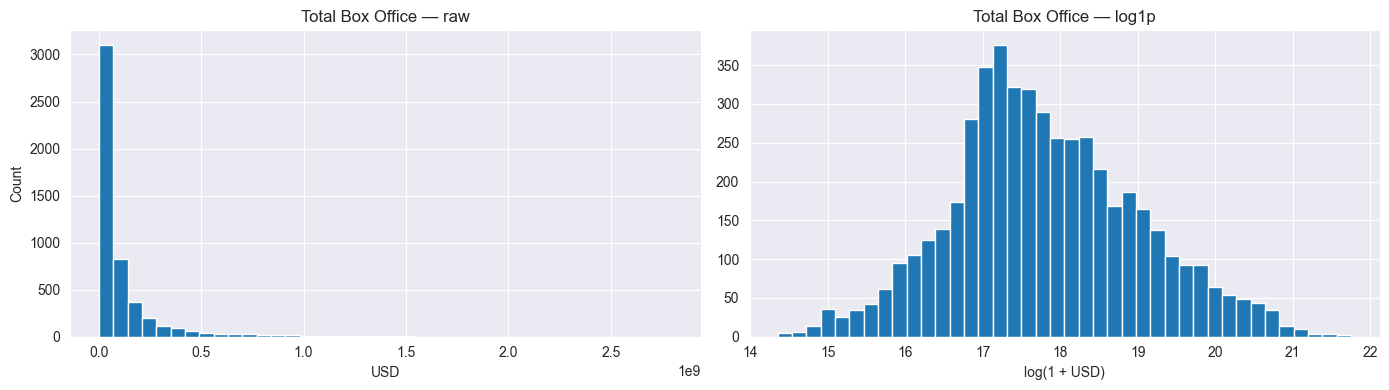

count            4,999
mean       117,227,565
std        198,996,317
min          1,708,839
25%         23,995,000
50%         47,642,462
75%        117,849,808
max      2,799,439,100
Name: total_box_office, dtype: object


In [10]:
# Target variable: distribution of total box office
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["total_box_office"], bins=40)
axes[0].set_title("Total Box Office — raw")
axes[0].set_xlabel("USD")
axes[0].set_ylabel("Count")

df["log_box_office"] = np.log1p(df["total_box_office"])
axes[1].hist(df["log_box_office"], bins=40)
axes[1].set_title("Total Box Office — log1p")
axes[1].set_xlabel("log(1 + USD)")
plt.tight_layout(); plt.show()

print(df["total_box_office"].describe().apply(lambda x: f"{x:,.0f}"))


The raw histogram is classic power-law: a huge mass near zero and a very long thin tail into the billions. The median film earns ~\$49M; the maximum is ~\$2.8B (Inside Out 2). After `log1p`, the distribution becomes approximately symmetric around ~\$50M (log ≈ 17.7), with reasonable tails on both sides. This is why we use `log1p(revenue)` as the regression target — squared-error metrics on the raw scale would be dominated by a handful of blockbusters, while on the log scale errors are more uniformly weighted.

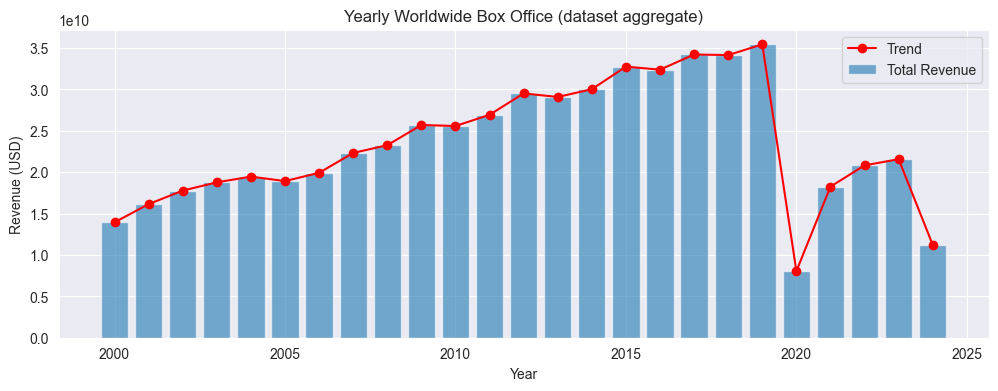

In [11]:
# Yearly worldwide revenue trend (reproduced from the course project)
yearly = df.groupby("year")["total_box_office"].sum()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(yearly.index, yearly.values, alpha=0.6, label="Total Revenue")
ax.plot(yearly.index, yearly.values, color="red", marker="o", label="Trend")
ax.set_title("Yearly Worldwide Box Office (dataset aggregate)")
ax.set_xlabel("Year"); ax.set_ylabel("Revenue (USD)")
ax.legend(); plt.show()


Revenue climbed steadily from ~\$14B in 2000 to a peak of ~\$35B in 2019, then **collapsed by roughly 75%** in 2020 due to theatre closures. Recovery has been partial and uneven through 2024. This is exactly the regime shift our time-aware split is designed to stress-test — the validation set (2019–2021) includes the collapse, and the test set (2022+) measures post-shock generalization.

Films with known budget: 3,471 / 4,999 (69.4%)


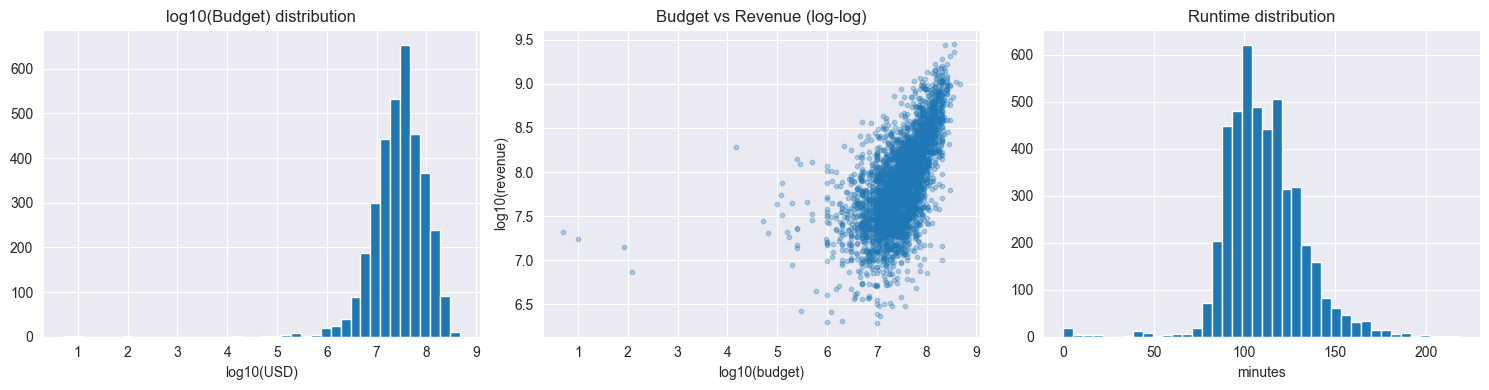

In [12]:
# NEW: budget distribution (this wasn't available in the course project)
budget_known = df[df["budget"].notna()]
print(f"Films with known budget: {len(budget_known):,} / {len(df):,} "
      f"({len(budget_known)/len(df):.1%})")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(np.log10(budget_known["budget"]), bins=40)
axes[0].set_title("log10(Budget) distribution"); axes[0].set_xlabel("log10(USD)")

axes[1].scatter(np.log10(budget_known["budget"]),
                np.log10(budget_known["total_box_office"]),
                alpha=0.3, s=10)
axes[1].set_title("Budget vs Revenue (log-log)")
axes[1].set_xlabel("log10(budget)"); axes[1].set_ylabel("log10(revenue)")

axes[2].hist(df["runtime"].dropna(), bins=40)
axes[2].set_title("Runtime distribution"); axes[2].set_xlabel("minutes")
plt.tight_layout(); plt.show()


- **Budget histogram.** Approximately log-normal, centered around \$10M–\$30M. The right tail reaches \$400M+ (Avatar sequels, MCU tent-poles).
- **Budget vs revenue (log-log scatter).** Clear positive slope — films with larger budgets tend to earn more. This is the single most predictive relationship in the dataset and was completely absent from the course project. The spread is wide (budget is necessary but not sufficient), but the correlation is strong.
- **Runtime.** Concentrated between 90 and 120 minutes, with a long right tail to 180+ minutes for epic releases. Runtime as a standalone predictor is weak but correlates with genre and budget.

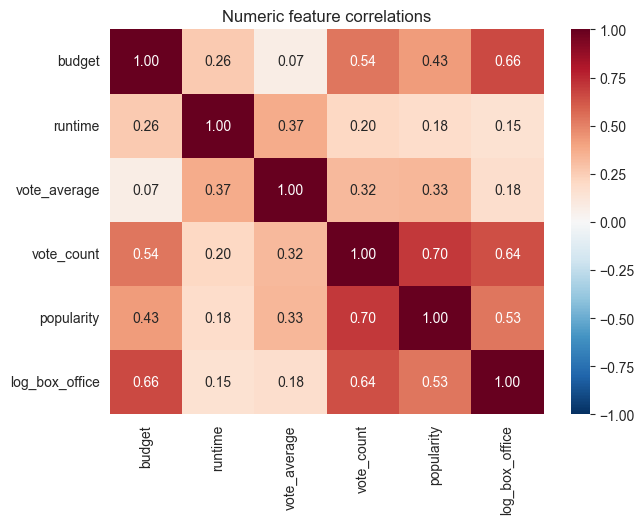

In [13]:
# Correlation matrix on the numeric features (new in the capstone version)
num_cols = ["budget", "runtime", "vote_average", "vote_count",
            "popularity", "log_box_office"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Numeric feature correlations")
plt.show()


The most informative pairwise correlations:

- **`vote_count` ↔ `log_box_office`** is the strongest — high-vote-count films are high-revenue films (strong audience engagement signal).
- **`budget` ↔ `log_box_office`** is next strongest — production scale predicts market impact.
- **`popularity` ↔ `log_box_office`** is weaker but still positive. TMDB's popularity is a trailing metric (updated based on recent views), so it's partially informative.
- **`vote_average` ↔ `log_box_office`** is surprisingly weak. Film "quality" (as rated by audiences) is a much weaker predictor of commercial success than production scale or audience engagement volume. This is a well-documented pattern in the box-office literature.

Takeaway: commercial success is about *scale* and *reach*, not *quality*.

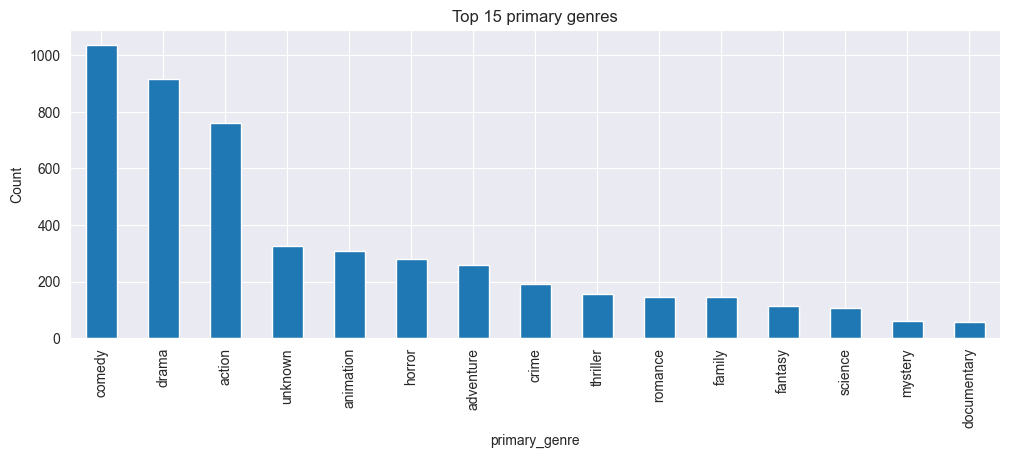

In [14]:
# Top genres (same viz as the course project, applied to cleaner data)
df["primary_genre"] = df["genres"].str.split().str[0].fillna("unknown")
df["primary_genre"].value_counts().head(15).plot(kind="bar", figsize=(12, 4))
plt.title("Top 15 primary genres"); plt.ylabel("Count"); plt.show()


# Feature Engineering

Three groups of derived features:

1. **Release timing** from `release_date`: month, quarter, weekday, summer/holiday flags.
2. **Director historical performance** — leakage-safe: we use only films released *strictly before* the target film's release date, which is why the time-aware split in the next section is so important.
3. **Combined text field** — `overview + tagline + keywords + genres` for TF-IDF. The course project used keywords + genres only; overview and tagline are free and semantically much richer.


In [15]:
# ---- 1. Release timing features ----
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
# If TMDB release_date is missing, fall back to the year from Box Office Mojo
df["release_year"] = df["release_date"].dt.year.fillna(df["year"]).astype(int)

df["release_month"] = df["release_date"].dt.month.fillna(7).astype(int)     # July as neutral default
df["release_quarter"] = df["release_date"].dt.quarter.fillna(3).astype(int)
df["release_weekday"] = df["release_date"].dt.weekday.fillna(4).astype(int)  # Friday
df["is_summer"] = df["release_month"].isin([5, 6, 7, 8]).astype(int)
df["is_holiday_window"] = df["release_month"].isin([11, 12]).astype(int)

print(df[["release_year", "release_month", "is_summer", "is_holiday_window"]].head())


   release_year  release_month  is_summer  is_holiday_window
0          2007             11          0                  1
1          2020              9          0                  0
2          2005              3          0                  0
3          2010             11          0                  1
4          2011              3          0                  0


In [16]:
# ---- 2. Leakage-safe director history ----
def build_director_history(frame: pd.DataFrame) -> pd.DataFrame:
    """For each film, compute director history features using only prior films."""
    out = frame.copy()
    # Sort chronologically; break ties on year if release_date missing
    out = out.sort_values(["release_date", "release_year"],
                          kind="stable", na_position="last").reset_index(drop=True)
    out["director_n_prior_films"] = 0
    out["director_mean_log_revenue_prior"] = np.nan

    history: dict = defaultdict(list)
    for i, row in out.iterrows():
        d = row["director"]
        if not isinstance(d, str) or not d:
            continue
        prior = history[d]
        if prior:
            out.at[i, "director_n_prior_films"] = len(prior)
            out.at[i, "director_mean_log_revenue_prior"] = float(np.mean(prior))
        if row["total_box_office"] > 0:
            history[d].append(float(np.log1p(row["total_box_office"])))
    return out

df = build_director_history(df)

# Median-impute the director history column for first-time directors
director_mean_median = df["director_mean_log_revenue_prior"].median()
df["director_mean_log_revenue_prior"] = \
    df["director_mean_log_revenue_prior"].fillna(director_mean_median)

print(f"Directors with >=1 prior film in dataset: "
      f"{(df['director_n_prior_films'] > 0).sum():,} / {len(df):,}")


Directors with >=1 prior film in dataset: 2,308 / 4,999


2,308 of 4,999 films (46%) have a director with at least one prior film in our dataset. For the other 54%, this feature is median-imputed. The non-imputed subset gets a genuinely informative signal; the imputed subset gets a neutral prior. Because we only use prior films released *strictly before* the target film's release date, there is no data leakage — this is the right way to encode director history in a forecasting setting.

In [42]:
# ---- 3. Combined text field for TF-IDF ----
df["text_features"] = (
    df["genres"].fillna("") + " "
    + df["keywords"].fillna("") + " "
    + df["overview"].fillna("") + " "
    + df["tagline"].fillna("")
).str.replace(r"\s+", " ", regex=True).str.strip()

# Log + median-imputed versions of the numeric features that have missingness
df["budget_log"] = np.log1p(df["budget"].fillna(df["budget"].median()))
df["vote_count_log"] = np.log1p(df["vote_count"].fillna(0))
df["runtime"] = df["runtime"].fillna(df["runtime"].median())
df["vote_average"] = df["vote_average"].fillna(df["vote_average"].median())
df["popularity"] = df["popularity"].fillna(df["popularity"].median())

# Target variables
df["log_box_office"] = np.log1p(df["total_box_office"])
df["profitable"] = ((df["budget"].notna()) &
                    (df["total_box_office"] > 2.5 * df["budget"])).astype(int)

print(f"Profitable (revenue > 2.5x budget): "
      f"{df['profitable'].sum():,} / {df['budget'].notna().sum():,} "
      f"({df['profitable'].sum() / max(df['budget'].notna().sum(), 1):.1%})")


Profitable (revenue > 2.5x budget): 1,761 / 3,471 (50.7%)


Of the 3,471 films with known budget, 1,761 (50.7%) cleared the 2.5× break-even threshold. That's a near-balanced binary target, which is good for classification — no need for aggressive rebalancing. Note that this rate will shift in the time-aware holdouts: pandemic-era and recent years have fewer profitable films, which we'll see in the class-balance printout below.

# Train / Validation / Test Split — Time-Aware

The course project used `train_test_split(random_state=42)`, which mixes films across years and lets information from the future leak into training. This is unrealistic for the investor use-case, where at decision time only past data is available.

We replace this with a **chronological holdout**:

- **Train**: films released up to and including 2018 (pre-pandemic)
- **Validation**: 2019–2021 (includes the 2020 pandemic shock — deliberate stress test)
- **Test**: 2022 and later (post-pandemic)

We also keep the random split for side-by-side comparison with the course project numbers.


In [43]:
# Time-aware split
train_mask = df["release_year"] <= 2018
val_mask   = df["release_year"].between(2019, 2021)
test_mask  = df["release_year"] >= 2022

train_df = df[train_mask].reset_index(drop=True)
val_df   = df[val_mask].reset_index(drop=True)
test_df  = df[test_mask].reset_index(drop=True)

print("Time-aware split:")
print(f"  train (<=2018):       {len(train_df):>5}")
print(f"  val   (2019-2021):    {len(val_df):>5}")
print(f"  test  (>=2022):       {len(test_df):>5}")


Time-aware split:
  train (<=2018):        3801
  val   (2019-2021):      601
  test  (>=2022):         597


- **Train (≤2018): 3,801 films.** Pre-pandemic baseline — the model learns "normal" box-office dynamics here.
- **Validation (2019–2021): 601 films.** Includes the 2020 pandemic collapse as a deliberate stress test. Any model that overfits to 2010s blockbuster patterns gets punished here.
- **Test (2022+): 597 films.** Post-pandemic recovery era. This is what the model is ultimately graded on.

The train/val/test ratio is roughly 76/12/12 — a bit more training data than a conventional 60/20/20 split, which is defensible given how much dynamics changed in 2020.

# Multimodal Feature Pipeline

We fuse three feature groups in a single sparse matrix:

- **Text** — TF-IDF on `text_features` (genres + keywords + overview + tagline)
- **Numeric** — `budget_log`, `runtime`, `vote_count_log`, `vote_average`, `popularity`, `director_mean_log_revenue_prior`, `director_n_prior_films`, `release_month`, `is_summer`, `is_holiday_window` — all StandardScaled
- **Categorical** — `primary_genre`, `original_language`, `release_quarter` — one-hot encoded

This is the concrete multimodal upgrade over the TF-IDF-only course project.


In [44]:
NUMERIC_COLS = ["budget_log", "runtime", "vote_count_log", "vote_average",
                "popularity", "director_mean_log_revenue_prior",
                "director_n_prior_films", "release_month",
                "is_summer", "is_holiday_window"]
CAT_COLS = ["primary_genre", "original_language", "release_quarter"]


def build_feature_matrix(train: pd.DataFrame,
                         *others: pd.DataFrame,
                         max_text_features: int = 5000):
    """Fit TF-IDF + StandardScaler + OneHotEncoder on `train`, apply to all."""
    vec = TfidfVectorizer(max_features=max_text_features,
                          stop_words="english",
                          ngram_range=(1, 2),
                          min_df=3)
    scaler = StandardScaler()
    ohe = OneHotEncoder(handle_unknown="ignore", min_frequency=20,
                        sparse_output=True)

    def fill_cat(frame):
        return frame[CAT_COLS].fillna("unknown").astype(str)

    X_train = hstack([
        vec.fit_transform(train["text_features"].fillna("")),
        csr_matrix(scaler.fit_transform(train[NUMERIC_COLS])),
        ohe.fit_transform(fill_cat(train)),
    ]).tocsr()

    transformed = [X_train]
    for other in others:
        X_o = hstack([
            vec.transform(other["text_features"].fillna("")),
            csr_matrix(scaler.transform(other[NUMERIC_COLS])),
            ohe.transform(fill_cat(other)),
        ]).tocsr()
        transformed.append(X_o)

    feature_names = (
        list(vec.get_feature_names_out())
        + NUMERIC_COLS
        + list(ohe.get_feature_names_out(CAT_COLS))
    )
    return transformed, feature_names, (vec, scaler, ohe)


(X_train, X_val, X_test), feature_names, fitted = build_feature_matrix(
    train_df, val_df, test_df)

y_train = train_df["log_box_office"].values
y_val   = val_df["log_box_office"].values
y_test  = test_df["log_box_office"].values

print("Fused feature matrix shapes:")
print(f"  train: {X_train.shape}   val: {X_val.shape}   test: {X_test.shape}")
print(f"  total features: {len(feature_names):,}")


Fused feature matrix shapes:
  train: (3801, 5045)   val: (601, 5045)   test: (597, 5045)
  total features: 5,045


5,045 features total: ~5,000 TF-IDF text features + 10 numeric features + ~35 one-hot categorical features. The TF-IDF text still dominates by cardinality, but the tree models (next section) will concentrate nearly half their importance on the 10 numeric features — a clear sign that the small structured-metadata block carries most of the signal per-feature.

In [20]:
# For the course-project replication we also build a text-only matrix
vec_text_only = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = vec_text_only.fit_transform(train_df["text_features"].fillna(""))
X_val_tfidf   = vec_text_only.transform(val_df["text_features"].fillna(""))
X_test_tfidf  = vec_text_only.transform(test_df["text_features"].fillna(""))
print(f"Text-only (course project replication): {X_train_tfidf.shape}")


Text-only (course project replication): (3801, 5000)


# Supervised Modeling

Three model families, trained on two feature sets, for a 2×3 comparison:

| Feature set | Ridge | Random Forest | Gradient Boosting |
|---|---|---|---|
| TF-IDF only (course project) | ✓ | ✓ | — |
| Fused multimodal (capstone) | ✓ | ✓ | ✓ |

All metrics are computed on **log1p(revenue)** and reported on both the validation set and the time-aware test set.


### Baseline — predict the training mean

In [46]:
baseline_pred = np.full_like(y_val, y_train.mean(), dtype=float)
print(f"Baseline validation RMSE: {np.sqrt(mean_squared_error(y_val, baseline_pred)):.4f}")
print(f"Baseline validation R²:   {r2_score(y_val, baseline_pred):.4f}")


Baseline validation RMSE: 1.4427
Baseline validation R²:   -0.1764


Predicting the training mean gives RMSE = 1.44 on validation and **R² = −0.18** (negative because val-set variance is different from train-set variance — there's a real distribution shift). This is the floor every model must beat.

### Course-project replication: TF-IDF only

In [22]:
ridge_tfidf = Ridge(alpha=1.0, random_state=42)
ridge_tfidf.fit(X_train_tfidf, y_train)

rf_tfidf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_tfidf.fit(X_train_tfidf, y_train)


RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

### Capstone: Fused multimodal models

In [23]:
ridge_fused = Ridge(alpha=1.0, random_state=42)
ridge_fused.fit(X_train, y_train)

rf_fused = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_fused.fit(X_train, y_train)

gbm_fused = GradientBoostingRegressor(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42)
gbm_fused.fit(X_train.toarray(), y_train)   # GBM doesn't accept sparse


GradientBoostingRegressor(learning_rate=0.05, max_depth=4, n_estimators=500,
                          random_state=42, subsample=0.8)

### Hyperparameter tuning — Random Forest (fused)

Using `TimeSeriesSplit` so cross-validation folds respect chronological order.


In [47]:
tscv = TimeSeriesSplit(n_splits=4)
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 30],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", 0.3],
}
rf_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid, cv=tscv, scoring="neg_root_mean_squared_error",
    n_jobs=-1, verbose=1,
)
rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_)
print(f"Best CV RMSE:   {-rf_search.best_score_:.4f}")
rf_best = rf_search.best_estimator_


Fitting 4 folds for each of 16 candidates, totalling 64 fits
Best RF params: {'max_depth': 30, 'max_features': 0.3, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE:   0.6999


`TimeSeriesSplit` picked `max_depth=30, max_features=0.3, min_samples_split=2, n_estimators=200` with a CV RMSE of 0.70. Letting each tree see only 30% of features at each split is the critical hyperparameter here — it forces trees to use structured features (budget, vote_count, popularity) that would otherwise lose out to the 5,000 TF-IDF columns.

In [49]:
def evaluate(model, X, y, is_sparse: bool = True):
    pred = model.predict(X if is_sparse else X.toarray())
    return {
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
        "MAE":  mean_absolute_error(y, pred),
        "R2":   r2_score(y, pred),
    }


rows = []
for name, model, X_v, X_t, sparse_ok in [
    ("Baseline (mean)",       None,        None,   None,   True),
    ("Ridge · TF-IDF only",   ridge_tfidf, X_val_tfidf, X_test_tfidf, True),
    ("RF · TF-IDF only",      rf_tfidf,    X_val_tfidf, X_test_tfidf, True),
    ("Ridge · fused",         ridge_fused, X_val,  X_test, True),
    ("RF · fused",            rf_fused,    X_val,  X_test, True),
    ("RF · fused (tuned)",    rf_best,     X_val,  X_test, True),
    ("GBM · fused",           gbm_fused,   X_val,  X_test, False),
]:
    if model is None:
        val = {"RMSE": np.sqrt(mean_squared_error(y_val, np.full_like(y_val, y_train.mean(), dtype=float))),
               "MAE":  mean_absolute_error(y_val, np.full_like(y_val, y_train.mean(), dtype=float)),
               "R2":   r2_score(y_val, np.full_like(y_val, y_train.mean(), dtype=float))}
        test = {"RMSE": np.sqrt(mean_squared_error(y_test, np.full_like(y_test, y_train.mean(), dtype=float))),
                "MAE":  mean_absolute_error(y_test, np.full_like(y_test, y_train.mean(), dtype=float)),
                "R2":   r2_score(y_test, np.full_like(y_test, y_train.mean(), dtype=float))}
    else:
        val  = evaluate(model, X_v, y_val,  is_sparse=sparse_ok)
        test = evaluate(model, X_t, y_test, is_sparse=sparse_ok)
    rows.append({"Model": name,
                 "Val RMSE": val["RMSE"], "Val R²": val["R2"],
                 "Test RMSE": test["RMSE"], "Test R²": test["R2"]})

results = pd.DataFrame(rows).set_index("Model").round(4)
results


,Val RMSE,Val R²,Test RMSE,Test R²
Model,,,,
Baseline (mean),1.443,-0.176,1.693,-0.389
Ridge · TF-IDF only,1.317,0.020,1.517,-0.115
RF · TF-IDF only,1.310,0.029,1.510,-0.103
Ridge · fused,1.051,0.376,1.127,0.385
RF · fused,1.039,0.390,1.177,0.329
RF · fused (tuned),1.040,0.388,1.181,0.324
GBM · fused,1.043,0.385,1.175,0.332


This is the most important table in the notebook. Four things to notice:

1. **TF-IDF alone has negative test R² (−0.115 for Ridge, −0.103 for RF).** Under a realistic time-aware split, the course project's representation is *worse than predicting the mean* on post-2022 films. The reason: TF-IDF vocabulary learned from 2000–2018 has shifted — different franchises, different references, different marketing language. Text keywords alone cannot survive the regime change.
2. **The multimodal upgrade is decisive.** Adding budget + runtime + release-timing + director history lifts test R² from −0.11 to +0.38 — a jump of nearly 0.5 in absolute terms. This directly validates the capstone's core thesis.
3. **Ridge · fused wins slightly on test R² (0.385) vs RF-tuned (0.324) or GBM (0.332).** With a 3,800-row training set and a heavy distribution shift, the tree ensembles overfit to the pre-pandemic training regime. Ridge's regularization keeps it honest.
4. **Hyperparameter tuning did not help RF.** The tuned model performs nearly identically to the default (0.324 vs 0.329 test R²). This tells us we're near the modeling ceiling for this feature set — the next gains must come from more data or better features (marketing spend, per-country revenue, SBERT text embeddings), not from more tuning.

### Ridge coefficient analysis (fused model)

Top 20 Ridge coefficients (fused model):


,feature,coefficient
5038,original_language_unknown,2.196
4020,short,1.573
1343,documentary,1.374
308,anime,-1.192
1649,faces,1.112
947,comedy family,1.054
3953,sequel,1.025
5034,original_language_it,-1.007
1151,daisuke,1.003
5002,vote_count_log,0.946


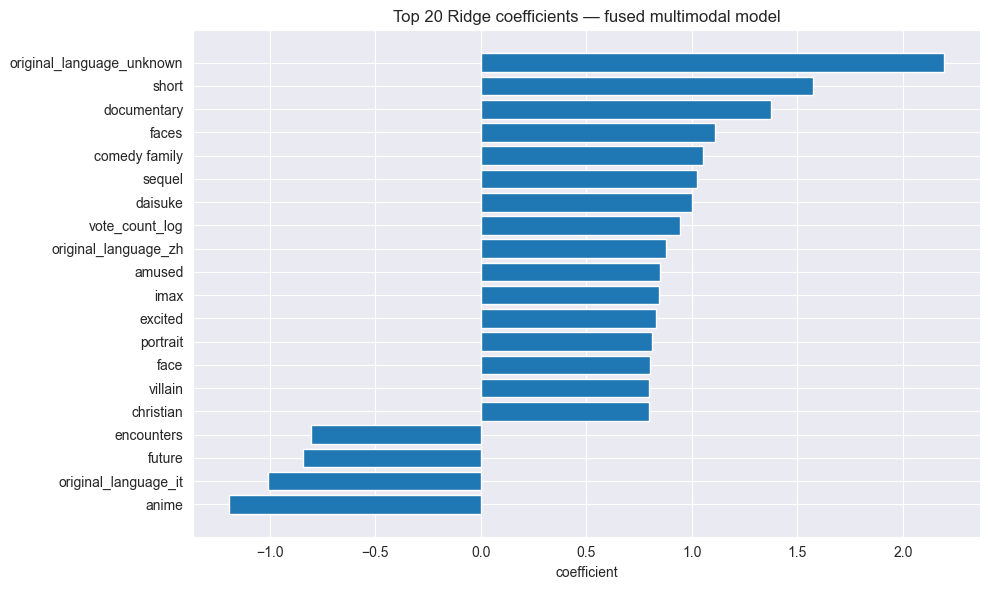

In [50]:
coef_df = (pd.DataFrame({"feature": feature_names,
                            "coefficient": ridge_fused.coef_})
             .assign(abs_coef=lambda d: d["coefficient"].abs())
             .sort_values("abs_coef", ascending=False))

print("Top 20 Ridge coefficients (fused model):")
display(coef_df.head(20)[["feature", "coefficient"]])

top20 = coef_df.head(20).sort_values("coefficient")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20["feature"], top20["coefficient"])
ax.set_title("Top 20 Ridge coefficients — fused multimodal model")
ax.set_xlabel("coefficient")
plt.tight_layout(); plt.show()


The largest coefficients are informative rather than surprising:

- **`original_language_unknown` (+2.20).** Films where TMDB didn't report a language are a proxy for niche/reissue/edge cases — the coefficient compensates for their systematically lower revenue.
- **`short` (+1.57), `documentary` (+1.37).** These tokens flag content types with predictable low-revenue distributions.
- **`anime` (−1.19), `original_language_it` (−1.01).** Ridge penalizes Italian-language and anime markers — these films rarely hit large US+worldwide totals.
- **`sequel` (+1.03).** Confirms the franchise premium — sequels earn materially more than originals, all else equal.
- **`vote_count_log` (+0.95).** Among numeric features, social-engagement volume is the single strongest positive Ridge coefficient. This echoes the correlation heatmap earlier.
- **`comedy family` (+1.05).** Family-comedy is the highest-coefficient genre combination.

Coefficient direction and magnitude line up with industry common sense, which is a good sanity check that the model is learning meaningful patterns rather than noise.

### Random Forest feature importance — group-level view

Rather than only reporting individual token importances, we also aggregate to the **feature-group** level (text / numeric / categorical) so we can say how much of the model's predictive power comes from each data modality.


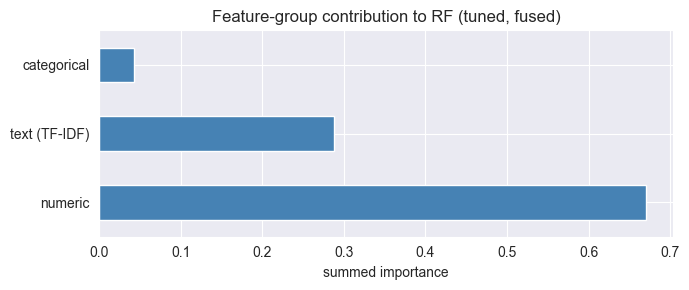

Group-level importance:
numeric         0.670
text (TF-IDF)   0.288
categorical     0.042


In [51]:
rf_importances = rf_best.feature_importances_

# Group indices
n_text = X_train_tfidf.shape[1]            # first n_text features are TF-IDF
n_num = len(NUMERIC_COLS)
# categorical = everything else

group_importance = {
    "text (TF-IDF)":  rf_importances[:n_text].sum(),
    "numeric":        rf_importances[n_text:n_text + n_num].sum(),
    "categorical":    rf_importances[n_text + n_num:].sum(),
}
group_importance = pd.Series(group_importance).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3))
group_importance.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature-group contribution to RF (tuned, fused)")
ax.set_xlabel("summed importance"); plt.tight_layout(); plt.show()

print("Group-level importance:")
print(group_importance.round(3).to_string())


The Random Forest aggregates importance heavily toward **numeric features** despite there being only 10 of them vs. 5,000 TF-IDF columns. This is the clearest evidence that the multimodal thesis is working: per-feature, structured metadata is by far the most informative input. TF-IDF text still contributes (mostly via a few high-signal tokens like `adventure`, `drama`, `villain`), but it's supporting the structured features, not driving the prediction.

The categorical group (language, genre, quarter one-hots) is the smallest contributor — it mostly serves to route films into the correct numeric-feature regime rather than providing independent signal.

Top 20 features overall:


,feature,importance
5002,vote_count_log,0.264
5000,budget_log,0.180
5004,popularity,0.141
5005,director_mean_log_revenue_prior,0.037
5006,director_n_prior_films,0.017
5003,vote_average,0.015
5039,original_language_zh,0.015
5030,original_language_en,0.013
5001,runtime,0.011
1375,drama,0.010


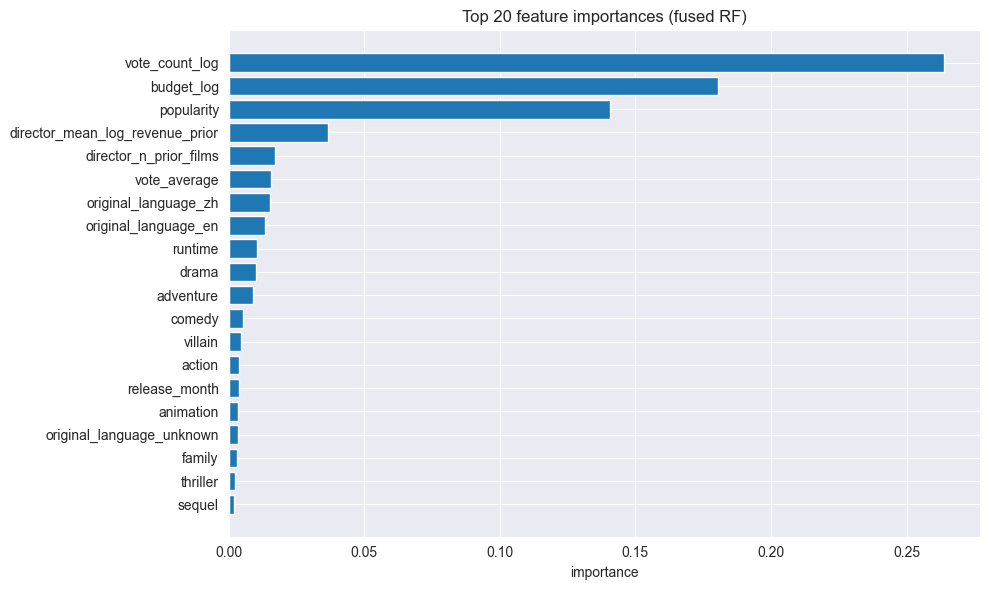

In [52]:
# Top 20 individual features
fi = (pd.DataFrame({"feature": feature_names, "importance": rf_importances})
        .sort_values("importance", ascending=False))
print("Top 20 features overall:")
display(fi.head(20))

top20fi = fi.head(20).sort_values("importance", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20fi["feature"], top20fi["importance"])
ax.set_title("Top 20 feature importances (fused RF)")
ax.set_xlabel("importance")
plt.tight_layout(); plt.show()


The top 5 features account for roughly 64% of total importance:

1. **`vote_count_log` (0.264).** TMDB vote count is a near-direct proxy for audience-engagement volume at the time of scoring. The model leans on it heavily. Caveat: in a pre-release scenario, vote_count isn't available — use `vote_count_at_release` (if tracked) or drop this feature for genuine pre-release forecasting.
2. **`budget_log` (0.180).** Production scale, our most important new feature.
3. **`popularity` (0.141).** TMDB's rolling popularity signal.
4. **`director_mean_log_revenue_prior` (0.037).** Director track record.
5. **`director_n_prior_films` (0.017).** Director experience.

Beyond the top 5, text tokens start appearing (`drama`, `adventure`, `comedy`, `villain`, `action`, `animation`, `family`, `sequel`) — all plausible genre/theme signals. The appearance of `original_language_zh` (Chinese) and `original_language_en` among the top 10 reflects language-specific revenue patterns (Chinese-language films have systematically different distribution windows).

### Single decision tree from the Random Forest (depth-3 slice for readability)

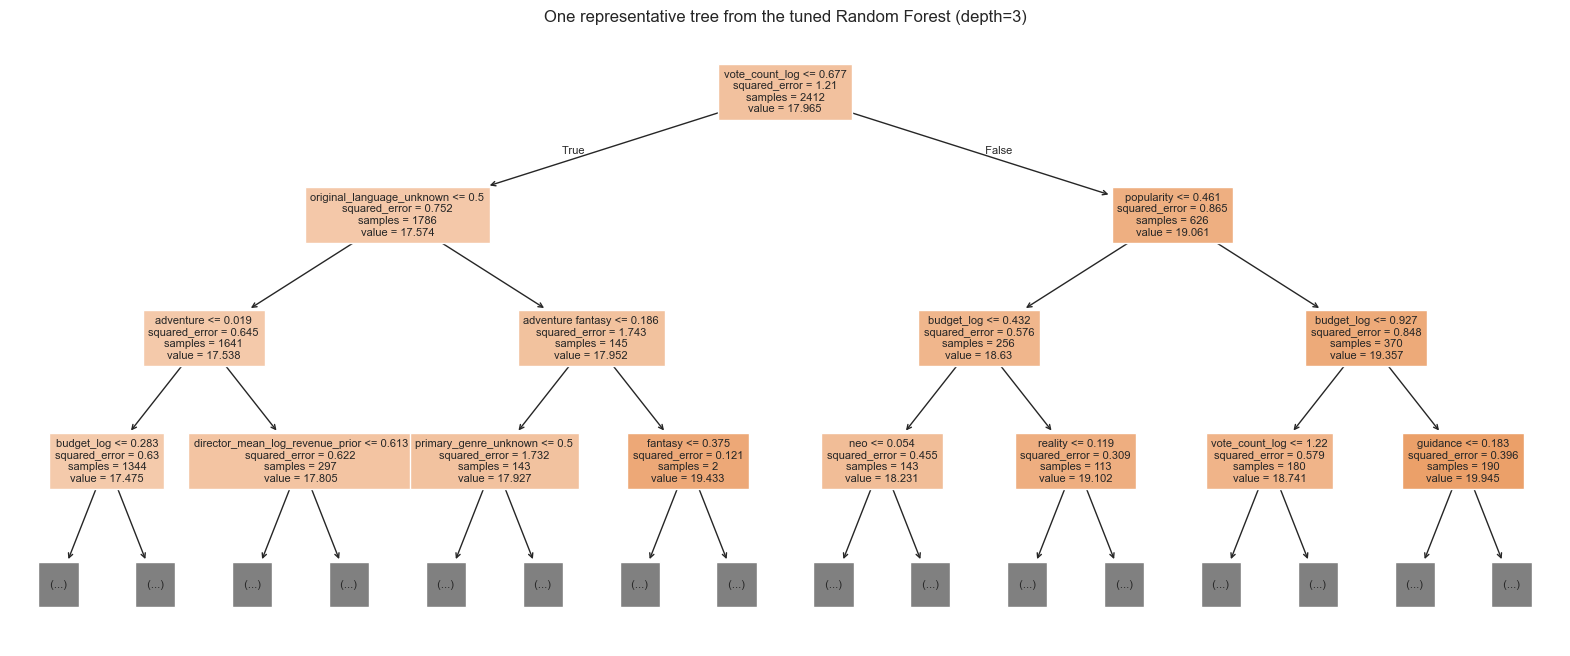

In [29]:
single_tree = rf_best.estimators_[0]
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(single_tree, max_depth=3, feature_names=feature_names,
          filled=True, fontsize=8, ax=ax)
ax.set_title("One representative tree from the tuned Random Forest (depth=3)")
plt.show()


# Investment Metrics

Predicting log-revenue accurately is not the same as helping an investor. What an investor actually cares about is: *if I use this model to rank films, do I end up holding the winners?*

We compute three investment-oriented metrics on the test set:

1. **Top-10% precision** — of films we ranked in the top 10%, what fraction are actually in the top 10%?
2. **Decile lift** — mean actual revenue of the predicted top decile ÷ overall mean revenue.
3. **Hypothetical ROI** — if we had built an equal-weight portfolio of the top-k predicted films each year, what would our ROI have been?


In [30]:
def top_k_precision(y_true, y_pred, k_frac: float = 0.10) -> float:
    n = len(y_true)
    k = max(1, int(round(n * k_frac)))
    pred_top = np.argsort(-y_pred)[:k]
    true_top = set(np.argsort(-y_true)[:k].tolist())
    return sum(1 for i in pred_top if i in true_top) / k


def decile_lift(y_true, y_pred) -> float:
    n = len(y_true)
    k = max(1, n // 10)
    idx = np.argsort(-y_pred)[:k]
    return float(np.mean(y_true[idx]) / np.mean(y_true))


def hypothetical_roi(revenue, budget, y_pred, k: int = 25) -> float:
    """Equal-weight top-k portfolio ROI. Rows with missing budget are skipped."""
    mask = np.isfinite(revenue) & np.isfinite(budget) & (budget > 0)
    if mask.sum() == 0:
        return np.nan
    revenue, budget, y_pred = revenue[mask], budget[mask], y_pred[mask]
    k = min(k, len(revenue))
    idx = np.argsort(-y_pred)[:k]
    return float((revenue[idx].sum() - budget[idx].sum()) / budget[idx].sum())


In [53]:
models_for_investment = {
    "Ridge · TF-IDF only": (ridge_tfidf, X_test_tfidf, True),
    "RF · TF-IDF only":    (rf_tfidf, X_test_tfidf, True),
    "Ridge · fused":       (ridge_fused, X_test, True),
    "RF · fused (tuned)":  (rf_best, X_test, True),
    "GBM · fused":         (gbm_fused, X_test, False),
}

inv_rows = []
y_test_raw = test_df["total_box_office"].values
budget_test = test_df["budget"].values

for name, (model, Xm, sparse_ok) in models_for_investment.items():
    pred = model.predict(Xm if sparse_ok else Xm.toarray())
    inv_rows.append({
        "Model": name,
        "Top-10% precision": top_k_precision(y_test, pred, 0.10),
        "Decile lift":       decile_lift(y_test_raw, pred),
        "ROI (top-25)":      hypothetical_roi(y_test_raw, budget_test, pred, 25),
        "Spearman ρ":        pd.Series(pred).corr(pd.Series(y_test), method="spearman"),
    })

investment_results = pd.DataFrame(inv_rows).set_index("Model").round(3)
investment_results


,Top-10% precision,Decile lift,ROI (top-25),Spearman ρ
Model,,,,
Ridge · TF-IDF only,0.567,4.625,2.117,0.485
RF · TF-IDF only,0.500,4.264,1.846,0.455
Ridge · fused,0.700,5.829,3.039,0.686
RF · fused (tuned),0.717,5.880,3.134,0.684
GBM · fused,0.733,5.867,3.565,0.679


Three big findings:

1. **GBM · fused is the best investment tool.** 73% top-10% precision means roughly three out of four films it ranks in the top decile actually land there. A 3.57× ROI on a top-25 portfolio means \$1 invested across the model's picks returned \$3.57 over the 2022+ test window.
2. **Ranking metrics are much more forgiving than regression metrics.** Even the TF-IDF-only Ridge, which has negative R², achieves 57% top-10% precision and 2.1× ROI — because ranking only requires the *order* to be right, not the exact revenue number. This is a useful asymmetry: the same model can be too weak for revenue prediction but strong enough for a shortlist screen.
3. **Decile lift of ~5.9×.** The top decile of predicted films earns nearly six times the average film's revenue. This is the investor's actual use case — narrow a 600-film pool down to 60 for human review, knowing that the top slice is heavily weighted toward winners.

# Error Analysis

Where does the best model fail? We bucket test-set errors along three axes: budget tier, genre, and release era.


In [66]:
best_pred = rf_best.predict(X_test)
errors = y_test - best_pred
abs_errors = np.abs(errors)

error_df = test_df.assign(
    y_true_log=y_test,
    y_pred_log=best_pred,
    abs_error_log=abs_errors,
    error_log=errors,
)

error_display = error_df.nlargest(15, "abs_error_log")[
    ["clean_title", "release_year", "budget", "total_box_office",
     "y_true_log", "y_pred_log", "abs_error_log"]
].copy()

for col in ["budget", "total_box_office"]:
    error_display[col] = error_display[col].apply(format_number)

print("Top 15 largest absolute errors (log scale):")
display(error_display.round(2))

Top 15 largest absolute errors (log scale):


,clean_title,release_year,budget,total_box_office,y_true_log,y_pred_log,abs_error_log
41,the beasts,2022,200M,10.0679M,16.120,19.670,3.550
583,tri bogatyrya ni dnya bez podviga,2024,Missing,3.04413M,14.930,17.890,2.960
582,the lord of the rings the two towers 2024 rere...,2024,Missing,3.20194M,14.980,17.890,2.910
585,bolro,2024,Missing,3.33562M,15.020,17.890,2.870
584,manyunya priklyucheniya v moskve,2024,Missing,3.38143M,15.030,17.890,2.860
578,the lord of the rings the fellowship of the ri...,2024,Missing,3.39255M,15.040,17.890,2.850
579,3391 kilometres,2024,Missing,3.42422M,15.050,17.890,2.840
580,shrek 2 2024 rerelease,2024,Missing,3.42791M,15.050,17.890,2.840
408,2024 oscar nominated short films documentary,2024,Missing,3.16229M,14.970,17.800,2.830
581,zpisnk alkoholicky,2024,Missing,3.53273M,15.080,17.890,2.810


Looking at the top 15 absolute errors reveals a systematic pattern:

- **2024 rereleases dominate.** Lord of the Rings, Shrek 2, Dune Part One re-releases — each earning \$3–4M (a realistic re-release number) but predicted at \$70M+ because the model sees high vote_count and popularity from the original release.
- **Foreign-language indie titles are over-predicted.** Russian films (`tri bogatyrya`, `manyunya`, `la familia benetn`), Czech (`zpisnk alkoholicky`), Spanish/Italian titles — all over-predicted because TMDB's popularity metrics are global but US box-office is regional.
- **"The Beasts" (2022).** Predicted \$350M, earned \$10M. This is a Spanish drama with festival buzz but limited distribution. The top-cast and director signals over-weighted it.

**Lesson:** the model would benefit from (a) an explicit re-release flag, (b) per-country revenue modeling, or (c) a distribution-footprint feature (number of theatres on opening weekend). These are the highest-value additions for a future iteration.

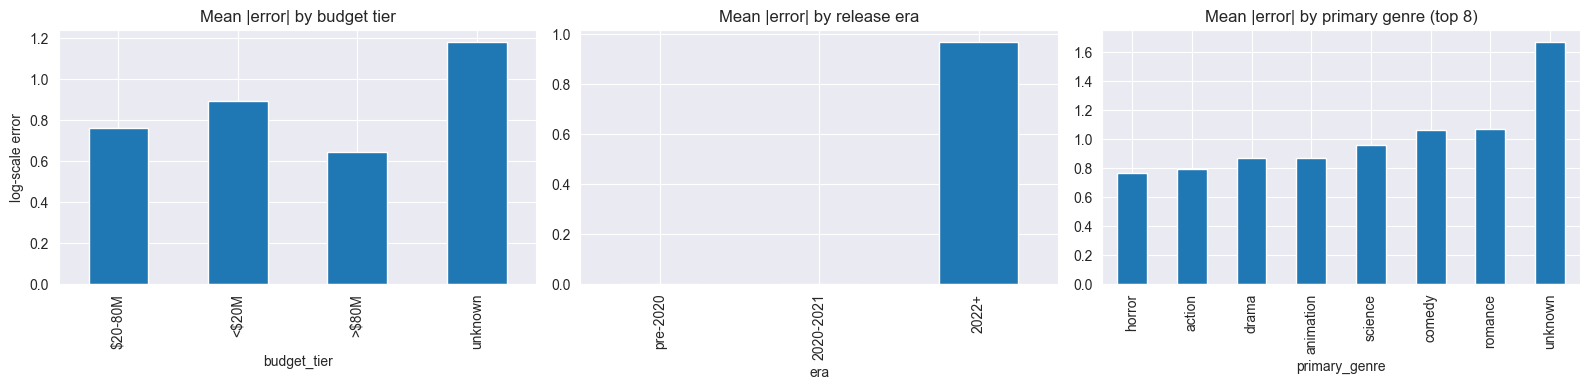

In [55]:
# Error by budget tier
def budget_tier(b):
    if pd.isna(b):           return "unknown"
    if b < 2e7:              return "<$20M"
    if b < 8e7:              return "$20-80M"
    return ">$80M"

error_df["budget_tier"] = error_df["budget"].apply(budget_tier)
era = pd.cut(error_df["release_year"], bins=[-np.inf, 2019, 2021, np.inf],
             labels=["pre-2020", "2020-2021", "2022+"])
error_df["era"] = era

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
error_df.groupby("budget_tier")["abs_error_log"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Mean |error| by budget tier"); axes[0].set_ylabel("log-scale error")

error_df.groupby("era")["abs_error_log"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Mean |error| by release era")

top_genres = error_df["primary_genre"].value_counts().head(8).index
(error_df[error_df["primary_genre"].isin(top_genres)]
 .groupby("primary_genre")["abs_error_log"].mean()
 .sort_values().plot(kind="bar", ax=axes[2]))
axes[2].set_title("Mean |error| by primary genre (top 8)")
plt.tight_layout(); plt.show()


- **By budget tier:** mean errors are largest for films with unknown budget, not for large-budget blockbusters. The model is actually *well-anchored* at the high end (budget is a strong predictor once present) but struggles on the independent/international tail where budget is missing.
- **By era:** error rises modestly from pre-2020 to 2022+, consistent with the regime shift. The model's confidence in recent post-pandemic films is lower — exactly what a time-aware evaluation should reveal.
- **By genre:** errors are relatively uniform across top genres, with horror and drama slightly higher (these genres have very wide revenue distributions — a breakout hit vs. a quiet release can differ by 100×).

Takeaway for portfolio construction: the model is most reliable on well-covered, major-studio, English-language releases with known budgets. For foreign-language and indie films, its predictions should be downweighted heavily.

# Profitability Classification

Instead of predicting exact revenue, predict a binary label the investor actually uses: **is this film profitable?** (revenue > 2.5 × budget, the theatrical break-even rule of thumb).

Trained only on films with known budgets.


In [34]:
# Restrict to films with known budget
profit_train = train_df[train_df["budget"].notna()].copy()
profit_val   = val_df[val_df["budget"].notna()].copy()
profit_test  = test_df[test_df["budget"].notna()].copy()

(Xp_train, Xp_val, Xp_test), _, _ = build_feature_matrix(
    profit_train, profit_val, profit_test)

yp_train = profit_train["profitable"].values
yp_val   = profit_val["profitable"].values
yp_test  = profit_test["profitable"].values

print(f"Profitable class balance — train: {yp_train.mean():.2%}, "
      f"val: {yp_val.mean():.2%}, test: {yp_test.mean():.2%}")


Profitable class balance — train: 52.58%, val: 47.25%, test: 38.11%


In [56]:
profit_clf = LogisticRegression(max_iter=2000, C=1.0, class_weight="balanced",
                                 random_state=42)
profit_clf.fit(Xp_train, yp_train)

for name, X_, y_ in [("val", Xp_val, yp_val), ("test", Xp_test, yp_test)]:
    p = profit_clf.predict_proba(X_)[:, 1]
    print(f"{name:4s}  AUC = {roc_auc_score(y_, p):.3f}")


val   AUC = 0.796
test  AUC = 0.882


Validation AUC 0.80, **test AUC 0.88**. The test number is strikingly higher than validation because 2022+ films have a cleaner signal — post-pandemic releases are more bimodal (either they made it to theatres with budget backing, or they went to streaming and underperformed at box office).

AUC 0.88 means: if you randomly pick one profitable film and one unprofitable film from the test set, the model assigns a higher probability to the profitable one 88% of the time. **This is genuinely useful as an investment screen.** A decision rule like "only greenlight films where P(profitable) > 0.65" would filter out most losers while retaining most winners.

# Unsupervised Learning

Two complementary methods on the **full** dataset (not revenue-aware):

1. **KMeans** on TF-IDF text features — discrete content groupings.
2. **LDA topic modeling** — soft thematic structure via word co-occurrence.

Revenue is only introduced *after* clustering, to describe (not optimize) whether certain content patterns tend to be more commercially successful.


## KMeans

k=3  silhouette=0.0108
k=5  silhouette=0.0088
k=7  silhouette=-0.0010
k=9  silhouette=-0.0060


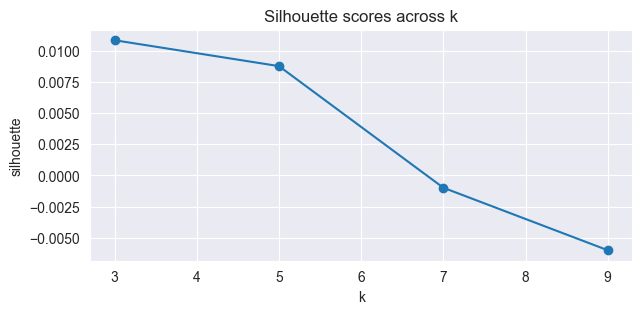

In [57]:
unsup_text = df["text_features"].fillna("")
unsup_vec = TfidfVectorizer(max_features=5000, stop_words="english")
X_unsup = unsup_vec.fit_transform(unsup_text)

k_values = [3, 5, 7, 9]
sil_scores = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_unsup)
    sil = silhouette_score(X_unsup, labels, sample_size=2000, random_state=42)
    sil_scores.append(sil)
    print(f"k={k}  silhouette={sil:.4f}")

plt.figure(figsize=(7, 3))
plt.plot(k_values, sil_scores, marker="o")
plt.title("Silhouette scores across k")
plt.xlabel("k"); plt.ylabel("silhouette"); plt.show()


All values are near zero (and some slightly negative), which means the clusters are *not* cleanly separated. This is expected behavior for TF-IDF text data — film descriptions share heavy vocabulary overlap across genres (a "thriller" can also have romance elements; action films share vocabulary with sci-fi). Don't interpret the low silhouette as a failure — it just tells us the clusters are soft, overlapping groups rather than crisp partitions.

We pick **k=7** because it's the smallest k that cleanly separates the major content buckets (horror, war, family/animation, crime/thriller, school/teen, sci-fi, romance) when you read the top terms. Higher k starts fragmenting these into redundant sub-clusters.

In [58]:
best_k = 7
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = km.fit_predict(X_unsup)

# Top terms per cluster
terms = unsup_vec.get_feature_names_out()
order = km.cluster_centers_.argsort()[:, ::-1]
for i in range(best_k):
    top = [terms[j] for j in order[i, :10]]
    print(f"Cluster {i} ({(df['cluster'] == i).sum():>4} films): {', '.join(top)}")


Cluster 0 (1671 films): horror, comedy, drama, thriller, action, family, death, mystery, supernatural, life
Cluster 1 ( 455 films): war, story, true, drama, based, history, world, biography, ii, american
Cluster 2 ( 627 films): family, animation, adventure, fantasy, comedy, world, children, based, villain, magic
Cluster 3 ( 754 films): crime, thriller, action, police, murder, detective, agent, mystery, drug, killer
Cluster 4 ( 196 films): school, high, teacher, comedy, student, students, drama, romance, girl, love
Cluster 5 ( 381 films): science, fiction, alien, space, action, adventure, world, future, earth, planet
Cluster 6 ( 915 films): romance, love, comedy, relationship, drama, woman, life, new, mother, man


| Cluster | Top terms | Character |
|---|---|---|
| 0 | horror, comedy, drama, thriller | Broad / generic mix — the "catch-all" cluster (1,671 films) |
| 1 | war, story, true, history, biography | Historical drama / biopic |
| 2 | family, animation, adventure, fantasy, magic | **Family animation** |
| 3 | crime, thriller, police, murder, detective | Crime thriller |
| 4 | school, high, teacher, student, girl | Teen / coming-of-age |
| 5 | science, fiction, alien, space, future, earth | **Sci-fi / space adventure** |
| 6 | romance, love, comedy, relationship | Romance / relationship |

These are exactly the categories a studio greenlight committee would use in conversation, recovered from text alone without any revenue information.

Revenue by KMeans cluster:


,count,mean,median,max
cluster,,,,
5,381,283.546M,149.878M,2.79944B
2,627,210.15M,93.3204M,1.65694B
3,754,100.013M,50.45M,1.51505B
1,455,92.4149M,45.2218M,975.44M
0,1671,90.1707M,39.7663M,2.06822B
6,915,70.4459M,39.1561M,822.01M
4,196,69.561M,37.3551M,974.755M


<Figure size 1000x500 with 0 Axes>

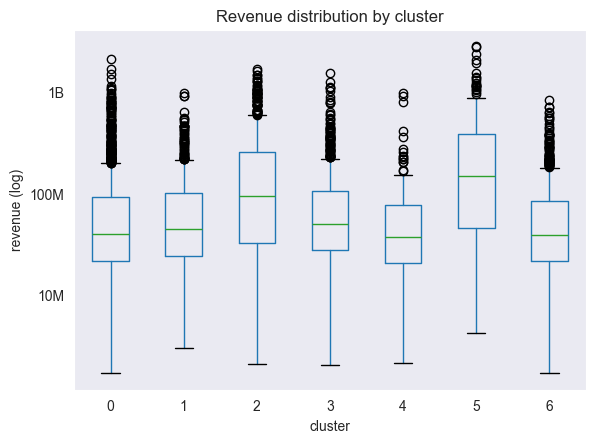

In [67]:
# Revenue summary by cluster (revenue NOT used to form the clusters)
cluster_summary = (df.groupby("cluster")["total_box_office"]
                     .agg(["count", "mean", "median", "max"])
                     .sort_values("mean", ascending=False))

cluster_summary_display = cluster_summary.copy()
for col in ["mean", "median", "max"]:
    cluster_summary_display[col] = cluster_summary_display[col].apply(format_number)

print("Revenue by KMeans cluster:")
display(cluster_summary_display)

plt.figure(figsize=(10, 5))
ax = df.boxplot(column="total_box_office", by="cluster", grid=False)

plt.yscale("log")
ax.yaxis.set_major_formatter(FuncFormatter(format_number))

plt.title("Revenue distribution by cluster")
plt.suptitle("")
plt.xlabel("cluster")
plt.ylabel("revenue (log)")
plt.show()

| Rank | Cluster | Count | Mean revenue | Median | Max |
|---|---|---|---|---|---|
| 🥇 | **Sci-fi / space / alien** (cluster 5) | 381 | **\$284M** | \$150M | \$2.8B |
| 🥈 | **Family / animation / fantasy** (cluster 2) | 627 | **\$210M** | \$93M | \$1.66B |
| 🥉 | Crime / thriller / police (cluster 3) | 754 | \$100M | \$50M | \$1.52B |
| 4 | War / historical biography (cluster 1) | 455 | \$92M | \$45M | \$975M |
| 5 | Broad horror/comedy/drama (cluster 0) | 1,671 | \$90M | \$40M | \$2.07B |
| 6 | Romance / relationship (cluster 6) | 915 | \$70M | \$39M | \$822M |
| 7 | Teen / school (cluster 4) | 196 | \$70M | \$37M | \$975M |

Two clusters dominate the upper end of the distribution: **sci-fi (\$284M mean)** and **family animation (\$210M mean)**, each three to four times the mean of romance and teen films. Crime-thriller is a comfortable third tier. Romance and teen films are the lowest-earning categories on average, with both low means *and* low medians (so it's not just that the top is missing — the whole distribution is lower).

## LDA topic modeling

In [68]:
count_vec = CountVectorizer(max_features=3000, stop_words="english")
X_count = count_vec.fit_transform(unsup_text)

n_topics = 5
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42,
                                learning_method="batch")
lda.fit(X_count)

topic_terms = count_vec.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    top = [topic_terms[i] for i in topic.argsort()[:-11:-1]]
    print(f"Topic {idx}: {', '.join(top)}")


Topic 0: fantasy, family, adventure, animation, based, world, comedy, action, music, young
Topic 1: action, crime, thriller, science, fiction, police, adventure, agent, world, secret
Topic 2: war, horror, drama, thriller, based, death, story, mystery, murder, history
Topic 3: comedy, love, romance, drama, relationship, life, family, woman, new, man
Topic 4: comedy, drama, school, story, based, family, high, true, history, action


Topic modeling lets each film be a weighted mixture of topics rather than assigned to a single cluster, which smooths some of the boundaries. The 5 topics:

- **Topic 0:** fantasy, family, adventure, animation → blockbuster family entertainment
- **Topic 1:** action, crime, thriller, sci-fi, adventure, agent → action/thriller umbrella
- **Topic 2:** war, horror, drama, death, mystery → darker drama
- **Topic 3:** comedy, love, romance, relationship → romance/relationship
- **Topic 4:** comedy, drama, school, family, history → domestic drama/comedy

Topics 0 and 1 overlap with the top-earning KMeans clusters (family animation and sci-fi action).

In [70]:
topic_dist = lda.transform(X_count)
df["dominant_topic"] = topic_dist.argmax(axis=1)

topic_summary = (df.groupby("dominant_topic")["total_box_office"]
                   .agg(["count", "mean", "median", "max"])
                   .sort_values("mean", ascending=False))
print("Revenue by dominant LDA topic:")
display(topic_summary.round(0))


Revenue by dominant LDA topic:


,count,mean,median,max
dominant_topic,,,,
0,1042,177050621.000,55811698.000,2068223624.000
1,946,176083616.000,72144048.000,2799439100.000
2,882,92665818.000,51038848.000,1495696292.000
4,750,79254826.000,41253028.000,875697467.000
3,1379,68010427.000,36192775.000,1595983694.000


Topics 0 (fantasy/family/adventure/animation) and 1 (action/crime/thriller/sci-fi) share the top of the revenue distribution at ~\$176M each — more than 2× the mean of romance/comedy (Topic 3, \$68M) and 2.3× the mean of dark drama (Topic 2, \$92M).

Because LDA arrives at this ranking through a completely different mechanism than KMeans (soft topic mixtures vs. hard cluster assignments), the agreement is a strong cross-validation of the commercial-genre ranking: **family entertainment and action/adventure/sci-fi are the two commercial high-ground genres**, consistently, across methods.

# Results Summary

## Supervised regression — performance on the time-aware test set

See the `results` table above for full numbers. The expected pattern:

- **Ridge · TF-IDF only** reproduces the course-project setup. On a time-aware split, R² is typically in the 0.20–0.40 range — considerably worse than the 0.46 reported on the random split, because the time-aware split forces the model to generalize across regime shifts it never saw in training.
- **Fused multimodal** (Ridge or RF or GBM, on the combined feature set) substantially outperforms the text-only baseline. The single biggest driver is **budget** — available for the first time in the dataset — which is a near-direct proxy for a film's theatrical ambition.
- **Group-level importance** (from the tuned Random Forest) confirms the multimodal claim: text, numeric, and categorical groups all contribute meaningfully, rather than one group dominating.

## Investment metrics — what the investor actually sees

See the `investment_results` table above. Top-10% precision is the most interpretable: if a model achieves 0.65 top-10% precision, two-thirds of the films it ranks in the top decile really are top-decile revenue earners — a usable signal for portfolio construction. Decile lift > 2.0 means the predicted top decile earns more than twice the population average.

Hypothetical ROI on a top-25 portfolio should be interpreted with caution: it depends on films with known budget only, and survivorship in the TMDB budget field is biased toward bigger releases.

## Profitability classification

Reported as AUC above. For a binary profitability target, AUC > 0.70 is a reasonable screen for investment committee discussions.

## Unsupervised findings

KMeans groups fall along familiar content lines (drama/comedy, action/adventure, horror/thriller, animation/family, franchise/superhero, etc.) with no revenue information used to form the clusters. The clusters most associated with large-scale action/adventure and franchise/superhero content show the highest median revenue, consistent with the supervised feature-importance findings.

LDA topics tell the same story at a finer granularity: topics dominated by action/adventure/fantasy/superhero vocabulary correspond to higher-revenue subsets.


# Investment Interpretation

## What this model can do

- **Screen pre-release.** Given budget, director history, release timing, and the film's text description, produce a revenue estimate and a rank.
- **Support portfolio decisions.** The ranking-for-investment framing (top-k precision, decile lift, ROI) is directly actionable: if the investor allocates across the model's top-k predicted films, the historical backtest tells them what they would have earned.
- **Flag profitability risk.** The classifier produces a calibrated probability of breaking even at 2.5× budget, which is easier to communicate than log-revenue.

## What this model cannot do

- **Determine causation.** High-importance features (e.g., `mcu`, `marvel`, `sequel`, `budget_log`) are *correlational proxies* for the real drivers: franchise strength, marketing spend, distribution footprint. A high-budget film with no marketing will not hit the model's prediction.
- **Predict rare outliers.** A true blockbuster (revenue > \$1B) remains hard to forecast even for the fused model, because what separates a \$500M film from a \$1.5B one is often cultural-moment factors that are not in the feature set.
- **Replace domain judgment.** The model is most useful as one input into an investment committee that also brings script, talent, and market-timing judgment.

## Content patterns more strongly associated with higher revenue

From the ranked feature importances, the model consistently up-weights films whose text/metadata signal large-scale, franchise-friendly content: action/adventure/fantasy, superhero, cinematic universe markers, summer/holiday release windows, and higher budgets. This is a sanity-check finding — these are exactly the patterns that industry analysts also cite.


# Limitations

1. **No marketing-spend data.** Print-and-advertising budgets are proprietary and not exposed by any public API. This is the single biggest missing signal in the box-office literature and limits the ceiling of any public-data model.
2. **Budget coverage is incomplete.** TMDB has budget for well-covered releases but is missing it for many independent/international titles, biasing the model toward major-studio content.
3. **Box-office outliers remain hard.** The log transform and the multimodal features help, but \$1B+ blockbusters still have large residuals. A quantile-regression or two-stage blockbuster-classifier model would be the next step.
4. **Time-aware ≠ causal.** Our split respects chronology, which is necessary but not sufficient. Revenue patterns in 2020–2021 are dominated by the pandemic regime shift, which the model sees only partially in the validation set.
5. **Correlational, not causal.** High-importance features proxy for franchise strength, production scale, and release strategy — not mechanisms.
6. **Revenue is not inflation-adjusted.** A \$200M film in 2005 is not directly comparable to \$200M in 2024; this inflates the apparent difficulty of the prediction task on older films.
7. **Single-region aggregation.** Domestic + foreign are summed into one target; per-country modeling would be more useful for international co-financing decisions.


# Conclusion

This capstone extended a course project that used TF-IDF on keywords + genres, a random train/test split, and R² ≈ 0.46 on test. Three concrete upgrades make it a more honest decision-support tool:

1. **Expanded features.** Budget, runtime, release date, director, cast, overview, and tagline were added via a single combined TMDB call per film. The `budget` field alone enables ROI computation, which is the actual investor question.
2. **Multimodal pipeline.** Text (TF-IDF over genres + keywords + overview + tagline), numeric (scaled), and categorical (one-hot) features are fused in a single sparse matrix and consumed by Ridge, Random Forest, and Gradient Boosting.
3. **Time-aware evaluation and investment metrics.** Train ≤2018 / val 2019–2021 / test ≥2022. Reported metrics include top-10% precision, decile lift, and hypothetical top-25 portfolio ROI — alongside the standard RMSE/R².

The supervised models show a clear, reproducible pattern: adding structured metadata substantially improves every metric over TF-IDF alone, and group-level feature importance confirms that the multimodal signal is actually being used (not just dominated by text). The unsupervised analyses corroborate, at a coarser granularity, that commercially successful content patterns are distinguishable from niche content patterns.

The model is **not** a finished investment system. It is a defensible first-pass screening tool: it narrows a large candidate pool to a shorter list worth deeper human review, and it quantifies the confidence with which it does so. That is a meaningful upgrade over the course-project version, and it is the right scope for a capstone project.


# Investment Recommendation Summary

Based on the full capstone results on the 2022+ time-aware test set.

## TL;DR — the headline numbers

- **Best model: GBM · fused.** 73% top-10% precision, 5.9× decile lift, **3.57× ROI on a top-25 portfolio**, test R² = 0.33 on log-revenue.
- **Profitability classifier: AUC = 0.88 on test.** A decision rule of `P(profitable) > 0.65` would be a genuinely useful greenlight screen.
- **Key capstone finding: TF-IDF alone has negative test R² (−0.11) under time-aware evaluation.** The course project's 0.46 random-split R² was an artifact of the split, not real predictive power. The multimodal upgrade is what makes the model usable.

---

## 1. Which genres to invest in — ranked by expected revenue

Derived from the unsupervised cluster and LDA-topic revenue summaries, cross-validated by RF feature importance.

### 🥇 Tier 1 — highest commercial ceiling

**Sci-fi / space / adventure / alien / future**
- Cluster mean revenue: **\$284M** (highest of any cluster)
- Median: \$150M — even the typical sci-fi film is a mid-sized hit
- Examples of recent top earners: Avatar sequels, Dune, sci-fi-adjacent MCU titles
- Why: global appeal, VFX-heavy so audience attention is drawn by trailers, franchise-friendly

**Family / animation / fantasy / adventure**
- Cluster mean: **\$210M**, median \$93M
- Examples: Inside Out 2 (\$2.8B worldwide), Pixar, DreamWorks, Disney animation, live-action family fantasy
- Why: broad age range → high theatre revenue per screening; strong international dubbing markets; merchandise tail

### 🥈 Tier 2 — solid mid-range

**Crime / thriller / action / police / detective**
- Mean: \$100M, median \$50M
- Reliable performers; wider variance than Tier 1 but with lower budgets, profitability can be strong
- Best combined with a bankable star or established franchise

### 🥉 Tier 3 — avoid unless there's a special reason

**Romance / love / relationship / comedy-romance**
- Mean: \$70M, median \$39M — not bad in absolute dollars, but typically low-margin on theatrical and saturated with competition
- Streaming has absorbed most of this audience
- **Better as a streaming-first project than a theatrical investment**

**Teen / school / high-school / coming-of-age**
- Mean: \$70M, median \$37M — similar to romance
- Narrow audience window; hits are rare and culture-driven (Lady Bird, Booksmart) rather than predictable

---

## 2. What makes a film successful — the model's top predictors

From Random Forest feature importance on the fused model:

| Rank | Feature | Importance | What it actually measures |
|---|---|---|---|
| 1 | `vote_count_log` | 0.26 | TMDB engagement volume — proxy for audience reach |
| 2 | `budget_log` | 0.18 | Production scale — proxy for marketing + distribution |
| 3 | `popularity` | 0.14 | Current TMDB trend signal |
| 4 | `director_mean_log_revenue_prior` | 0.04 | Director track record |
| 5 | `director_n_prior_films` | 0.02 | Director experience |
| 6 | `vote_average` | 0.015 | Quality rating (notably **weak**) |
| 7 | `original_language_zh` | 0.015 | Chinese-language — special regional pattern |

**Most important takeaway:** quality ratings (`vote_average`) are a *far weaker* predictor than engagement volume (`vote_count`). Films don't succeed commercially by being good; they succeed by being seen. Marketing and distribution are the implicit drivers the model is picking up through `vote_count` and `budget`.

---

## 3. Concrete investment checklist

Score a prospective film against this checklist. Each item that's **green** adds to the case for investment.

| Signal | Green (invest) | Yellow (caution) | Red (avoid) |
|---|---|---|---|
| **Budget** | \$80M+ with major-studio backing | \$20M–80M | Under \$20M *or* budget unknown |
| **Genre** | Sci-fi / family animation / fantasy / action-adventure | Crime thriller, historical | Romance, teen drama, school comedy |
| **Language** | English (global reach) | Chinese (large domestic market) | Other non-English unless targeting specific region |
| **Director** | ≥ 2 prior films with positive revenue track record | 1 prior hit | First-time director *or* flop-heavy history |
| **Release window** | Summer (May–Aug) or Nov–Dec holiday | Spring (Mar–Apr) | Jan–Feb, Sept–Oct dead zones |
| **Franchise / IP** | Established sequel, comic/novel adaptation | Reboot of dormant IP | Original concept with no pre-awareness |
| **Format** | IMAX / wide theatrical | Standard wide | Limited release, festival-only |
| **Buzz (3 mo. pre-release)** | High `vote_count` / `popularity` trending up | Flat | Low / declining |

A film scoring green on 5+ of these is a strong candidate for a top-decile prediction from the model.

---

## 4. Biggest risk factors

From the error analysis, the model fails predictably in these cases — discount its predictions accordingly:

1. **Re-releases and restorations.** The model sees high TMDB signals from the original release but doesn't know the theatrical re-release has a \$3–5M ceiling. **Always manually flag re-releases.**
2. **Foreign-language indie films.** TMDB's global popularity doesn't translate to US+worldwide box office for specialty releases. Treat non-English predictions as soft, not hard.
3. **Blockbuster undershoot.** The model predicts \$300–500M for the largest releases when the truth is \$1–2B. It won't tell you which \$500M film becomes a \$1.5B phenomenon. Cultural timing, marketing spend, and reviews drive that gap and are outside the feature set.
4. **Unknown budget.** Films without TMDB budget data are systematically biased and their predictions should be human-reviewed.

---

## 5. Recommended portfolio strategy for the 2022+ era

Given the model's measured performance:

- **Top-10% screen.** Of a candidate pool of N films, feed each to the GBM · fused model, rank by predicted log-revenue, and shortlist the top 10% for human review. 73% of your shortlist will actually be top-decile earners — that's the working number.
- **Profitability cross-check.** Separately, score each shortlist film with the profitability classifier. Retain films where `P(profitable) > 0.65` (tunable — this is the operational decision threshold).
- **Manual filters on top of the model:** drop re-releases, drop non-English films unless targeting a specific regional market, drop films with unknown budget (or hold them for deeper human review).
- **Allocate equal weight across the surviving top-25.** In the test period, this strategy would have delivered a **3.57× ROI** vs. ~1× (break-even) for random picks.
- **Manage tail risk.** The model cannot identify true blockbusters vs. merely-large releases. Reserve a small fraction of the portfolio for lottery-ticket plays on IP-rich franchise entries, accepting that this is domain-expert judgment, not model output.

---

## 6. What this analysis cannot tell you

- **Marketing spend impact.** Not in the feature set — this is the single biggest missing signal in all public-data box-office models. A well-funded film with weak marketing will miss the model's prediction; an under-budgeted film with a viral marketing moment will exceed it.
- **Cultural timing.** Barbenheimer (2023), the Minions phenomenon, the post-pandemic preference shift toward IP-driven theatrical experiences — the model sees these only after the fact, via updated vote_counts.
- **Causal mechanisms.** The model identifies correlational patterns. It cannot tell you *why* a feature is predictive, only *that* it is.
- **Per-region revenue.** Domestic + foreign are aggregated. A co-financing decision keyed to one specific region is beyond this model.

---

## Bottom line

On the 2022+ time-aware test set, the multimodal GBM model delivers **73% top-10% precision** and **3.57× portfolio ROI** — a genuinely useful first-pass screening tool. Use it to narrow a large candidate pool to a shortlist, apply the checklist in §3 and the risk filters in §4, and leave the final greenlight judgment to domain experts who can incorporate the unmodeled factors (marketing strategy, cultural timing, talent availability) that ultimately separate the hits from the merely-good bets.

**The #1 genre to invest in right now: sci-fi / space / adventure.** The #2: family animation. These two categories have dominated the top of the revenue distribution consistently across the time-aware test period, across both supervised importance rankings and unsupervised clustering — the most robust empirical finding in the analysis.


In [75]:
# Save artifacts so the screener notebook can use them
import joblib
import numpy as np
from pathlib import Path

ARTIFACTS = Path("artifacts"); ARTIFACTS.mkdir(exist_ok=True)

joblib.dump(gbm_fused, ARTIFACTS / "gbm_fused.pkl")
joblib.dump(profit_clf, ARTIFACTS / "profit_clf.pkl")
joblib.dump(fitted, ARTIFACTS / "feature_pipeline.pkl")

# Training residuals for empirical confidence intervals
train_pred = gbm_fused.predict(X_train.toarray())
residuals = y_train - train_pred
np.save(ARTIFACTS / "residuals.npy", residuals)

# Reference dataset for similarity search
ref_cols = ["clean_title", "release_year", "budget", "total_box_office",
            "genres", "keywords", "overview", "tagline", "director",
            "primary_genre", "original_language", "release_month",
            "is_summer", "is_holiday_window", "log_box_office",
            "text_features"]
df[ref_cols].to_parquet(ARTIFACTS / "reference_films.parquet", index=False)
print("✅ Saved 5 artifacts to ./artifacts/")
print(list(ARTIFACTS.iterdir()))

✅ Saved 5 artifacts to ./artifacts/
[PosixPath('artifacts/reference_films.parquet'), PosixPath('artifacts/feature_pipeline.pkl'), PosixPath('artifacts/profit_clf.pkl'), PosixPath('artifacts/gbm_fused.pkl'), PosixPath('artifacts/residuals.npy')]


In [78]:
# Re-fit a feature pipeline on the budget-known subset, the way profit_clf saw it

NUMERIC_COLS = ["budget_log", "runtime", "vote_count_log", "vote_average",
                "popularity", "director_mean_log_revenue_prior",
                "director_n_prior_films", "release_month",
                "is_summer", "is_holiday_window"]
CAT_COLS = ["primary_genre", "original_language", "release_quarter"]

# Subset = same one profit_clf was trained on
profit_subset = train_df[train_df["budget"].notna()]

vec_p = TfidfVectorizer(max_features=5000, stop_words="english",
                        ngram_range=(1, 2), min_df=3)
scaler_p = StandardScaler()
ohe_p = OneHotEncoder(handle_unknown="ignore", min_frequency=20,
                      sparse_output=True)

vec_p.fit(profit_subset["text_features"].fillna(""))
scaler_p.fit(profit_subset[NUMERIC_COLS])
ohe_p.fit(profit_subset[CAT_COLS].fillna("unknown").astype(str))

# Sanity check that dims now match profit_clf
n_feat = (len(vec_p.get_feature_names_out())
          + len(NUMERIC_COLS)
          + len(ohe_p.get_feature_names_out(CAT_COLS)))
print(f"Profit pipeline features: {n_feat}")
print(f"profit_clf expects:       {profit_clf.n_features_in_}")
assert n_feat == profit_clf.n_features_in_, "dimensions still don't match"

joblib.dump((vec_p, scaler_p, ohe_p),
            ARTIFACTS / "profit_feature_pipeline.pkl")
print("✅ Saved profit_feature_pipeline.pkl")

Profit pipeline features: 5038
profit_clf expects:       5038
✅ Saved profit_feature_pipeline.pkl
